In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print("Path to dataset files:", path)

C:\Users\mayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|███████████████████████████████████████████████████████████████████████████████| 387M/387M [02:02<00:00, 3.33MB/s]

Extracting files...


Path to dataset files: C:\Users\mayan\.cache\kagglehub\datasets\phylake1337\fire-dataset\versions\1


In [9]:
import kagglehub

path = kagglehub.dataset_download("phylake1337/fire-dataset")
print("Path to dataset files:", path)

DATASET_DIR = path + "/fire_dataset"

Path to dataset files: C:\Users\mayan\.cache\kagglehub\datasets\phylake1337\fire-dataset\versions\1


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [22]:
DATASET_DIR = r"C:\Users\mayan\.cache\kagglehub\datasets\phylake1337\fire-dataset\versions\1\fire_dataset"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20
MODEL_OUT   = "fire_detection_model.h5"

In [23]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
)
 
train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
)
 
val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)
 
print("Class indices:", train_gen.class_indices)

Found 800 images belonging to 2 classes.
Found 199 images belonging to 2 classes.
Class indices: {'fire_images': 0, 'non_fire_images': 1}


In [24]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze pretrained weights for the first training phase
 
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)  # binary output: fire probability
 
model = Model(inputs=base_model.input, outputs=output)
 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
 
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(MODEL_OUT, monitor="val_accuracy", save_best_only=True),
]
 
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7517 - loss: 0.5204

25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8213 - loss: 0.4143 - val_accuracy: 0.8844 - val_loss: 0.2596
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9315 - loss: 0.2025

25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9300 - loss: 0.1948 - val_accuracy: 0.9548 - val_loss: 0.1689
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9542 - loss: 0.1563

25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9625 - loss: 0.1388 - val_accuracy: 0.9648 - val_loss: 0.1309
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9663 - loss: 0.1071 - val_accuracy: 0.9548 - val_loss: 0.1303
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9663 - loss: 0.0971 - val_accuracy: 0.9548 - val_loss: 0.1237
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9737 - loss: 0.0812 - val_accuracy: 0.9447 - val_loss: 0.1274
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9700 - loss: 0.0731 - val_accuracy: 0.9598 - val_loss: 0.1183
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9699 - loss: 0.0901

25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9750 - loss: 0.0791 - val_accuracy: 0.9698 - val_loss: 0.1005
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9879 - loss: 0.0557

25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9800 - loss: 0.0633 - val_accuracy: 0.9799 - val_loss: 0.0854
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9800 - loss: 0.0590 - val_accuracy: 0.9698 - val_loss: 0.0934
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9812 - loss: 0.0548 - val_accuracy: 0.9799 - val_loss: 0.0984
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9812 - loss: 0.0531 - val_accuracy: 0.9749 - val_loss: 0.1034
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9850 - loss: 0.0510 - val_accuracy: 0.9799 - val_loss: 0.0848
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9900 - loss: 0.0395 - val_accuracy: 0.9648 - val_loss: 0.1044
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9812 - loss: 0.0521 - val_accuracy: 0.9648 - val_loss: 0.1026
Epoch 16/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9837 - loss: 0.0423 - val_accuracy: 0.9749 - val_loss: 0.0

25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9887 - loss: 0.0417 - val_accuracy: 0.9849 - val_loss: 0.0743


In [26]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
 
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
 
fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8712 - loss: 0.3044 - val_accuracy: 0.9799 - val_loss: 0.0817
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9550 - loss: 0.1480 - val_accuracy: 0.9749 - val_loss: 0.0987
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9762 - loss: 0.1073 - val_accuracy: 0.9849 - val_loss: 0.0844
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9663 - loss: 0.0953 - val_accuracy: 0.9598 - val_loss: 0.1103
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9762 - loss: 0.0789 - val_accuracy: 0.9749 - val_loss: 0.0872


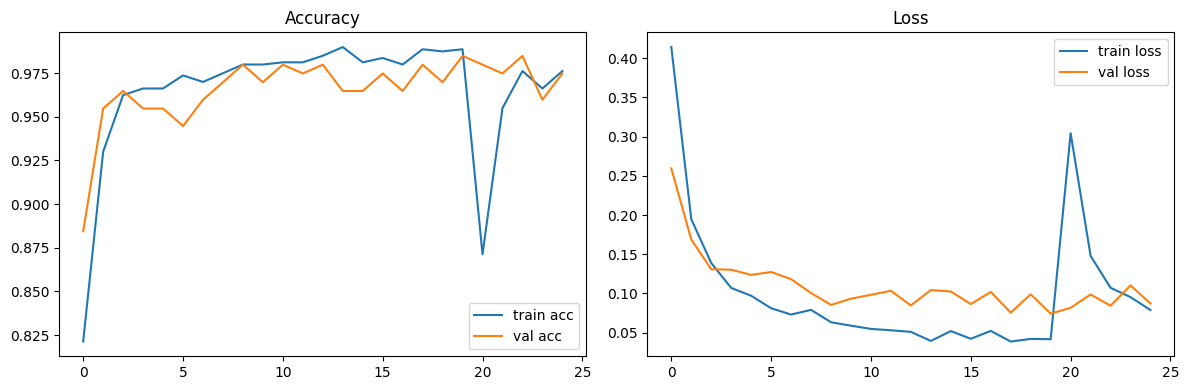

In [27]:
def plot_history(h1, h2=None):
    acc = h1.history["accuracy"] + (h2.history["accuracy"] if h2 else [])
    val_acc = h1.history["val_accuracy"] + (h2.history["val_accuracy"] if h2 else [])
    loss = h1.history["loss"] + (h2.history["loss"] if h2 else [])
    val_loss = h1.history["val_loss"] + (h2.history["val_loss"] if h2 else [])
 
    plt.figure(figsize=(12, 4))
 
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="train acc")
    plt.plot(val_acc, label="val acc")
    plt.title("Accuracy")
    plt.legend()
 
    plt.subplot(1, 2, 2)
    plt.plot(loss, label="train loss")
    plt.plot(val_loss, label="val loss")
    plt.title("Loss")
    plt.legend()
 
    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()
 
plot_history(history, fine_tune_history)

In [28]:
model.save(MODEL_OUT)
print(f"Model saved to {MODEL_OUT}")

Model saved to fire_detection_model.h5
